In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("Placement.csv")

In [3]:
dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [5]:
#1 Replace the NaN values with correct value.(Based on domain knowledge nan to be changed to 0)
dataset.fillna({"salary": 0}, inplace=True)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [6]:
#2 How many of them are not placed?
tot = dataset["status"]=="Not Placed"
tot.sum()

np.int64(67)

In [7]:
#3 Find the reason for non placement from the dataset
dataset.corr(numeric_only=True)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.002543
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823
salary,0.002543,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000


In [8]:
# 4 how is mba_p and salary related:IT is positively related 0.139823

In [9]:
#5 Which specialization is getting minimum salary
placed = dataset[dataset["status"] == "Placed"]
avg_salary = placed.groupby("specialisation")["salary"].median()
min_specialisation = avg_salary.idxmin()
min_salary = avg_salary.min()
print("Specialization with minimum salary:", min_specialisation)
print("Average salary:", min_salary)

Specialization with minimum salary: Mkt&HR
Average salary: 255000.0


In [10]:
#6 How many of them getting above 500000 salary?
ab50l=dataset["salary"]>500000
ab50l.sum()

np.int64(3)

In [11]:
#7 ANOVA one way
import scipy.stats as stats
stats.f_oneway(dataset['etest_p'],dataset['mba_p'])

F_onewayResult(statistic=np.float64(98.64487057324709), pvalue=np.float64(4.672547689133636e-21))

In [ ]:
#8 Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.
import pandas as pd
from scipy import stats

# Filter the two groups
group1 = dataset[dataset["degree_t"] == "Sci&Tech"]["salary"].dropna()
group2 = dataset[dataset["specialisation"] == "Mkt&HR"]["salary"].dropna()

# Perform independent t-test
t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test

print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H0: Salaries differ significantly between Sci&Tech and Mkt&HR")
else:
    print("Fail to reject H0: Salaries are statistically similar")


t-statistic: 2.584058295797713
p-value: 0.011110477852831742
Reject H0: Salaries differ significantly between Sci&Tech and Mkt&HR


In [ ]:
#9 Convert the normal distribution to standard normal distribution for salary(8)
import seaborn as sns
def stdNBgraph(dataset):
    mean = dataset.mean()
    std = dataset.std()
    values = [i for i in dataset]
    z_score = [((j-mean)/std) for j in values]
    sns.distplot(z_score,kde=True)
    sum(z_score)/len(z_score)

C:\Users\hemav\AppData\Local\Temp\ipykernel_10480\3093871753.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


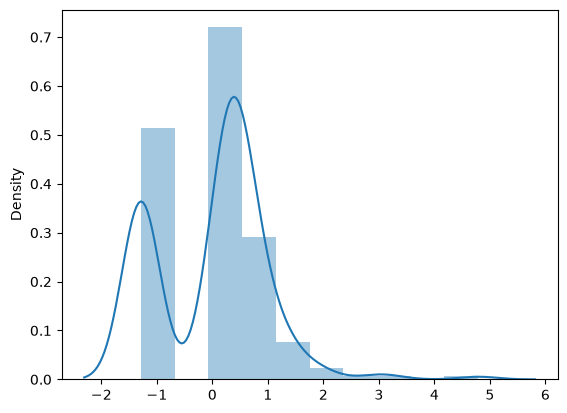

In [14]:
stdNBgraph(dataset['salary'])

In [ ]:
#10 Find pdf of given range.
from matplotlib import pyplot
from scipy.stats import norm
def get_pdf_prob(dataset,start,end):
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(start,color='Red')
    pyplot.axvline(end,color='Red')
    sample = dataset
    sample_mean = sample.mean()
    sample_std = sample.std()
    print("sample mean:",sample_mean)
    print("sample sd:",sample_std)
    dist = norm(sample_mean,sample_std)
    values = [value for value in range(start,end)]
    probab = [dist.pdf(value) for value in values]
    prob = sum(probab)
    return prob

C:\Users\hemav\AppData\Local\Temp\ipykernel_10480\88905860.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


sample mean: 198702.32558139536
sample sd: 154780.92671560097


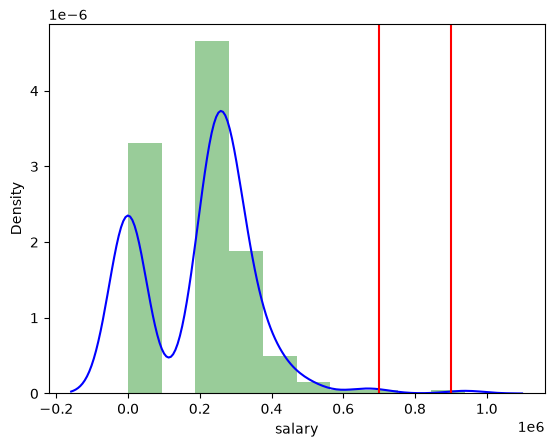

In [16]:
probability = get_pdf_prob(dataset['salary'], 700000, 900000)

In [ ]:
#11 Testing the similary based on given scenario
from scipy.stats import ttest_rel
spec1 = dataset[dataset["degree_t"]=='Sci&Tech)']['etest_p']
spec2 = dataset[dataset["degree_t"]=='Sci&Tech)']['mba_p']
ttest_rel(spec1,spec2)

C:\Users\hemav\AppData\Local\Temp\ipykernel_10480\3193491766.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_rel(spec1,spec2)


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [18]:
#12 ssc_p is highly correlated with salary

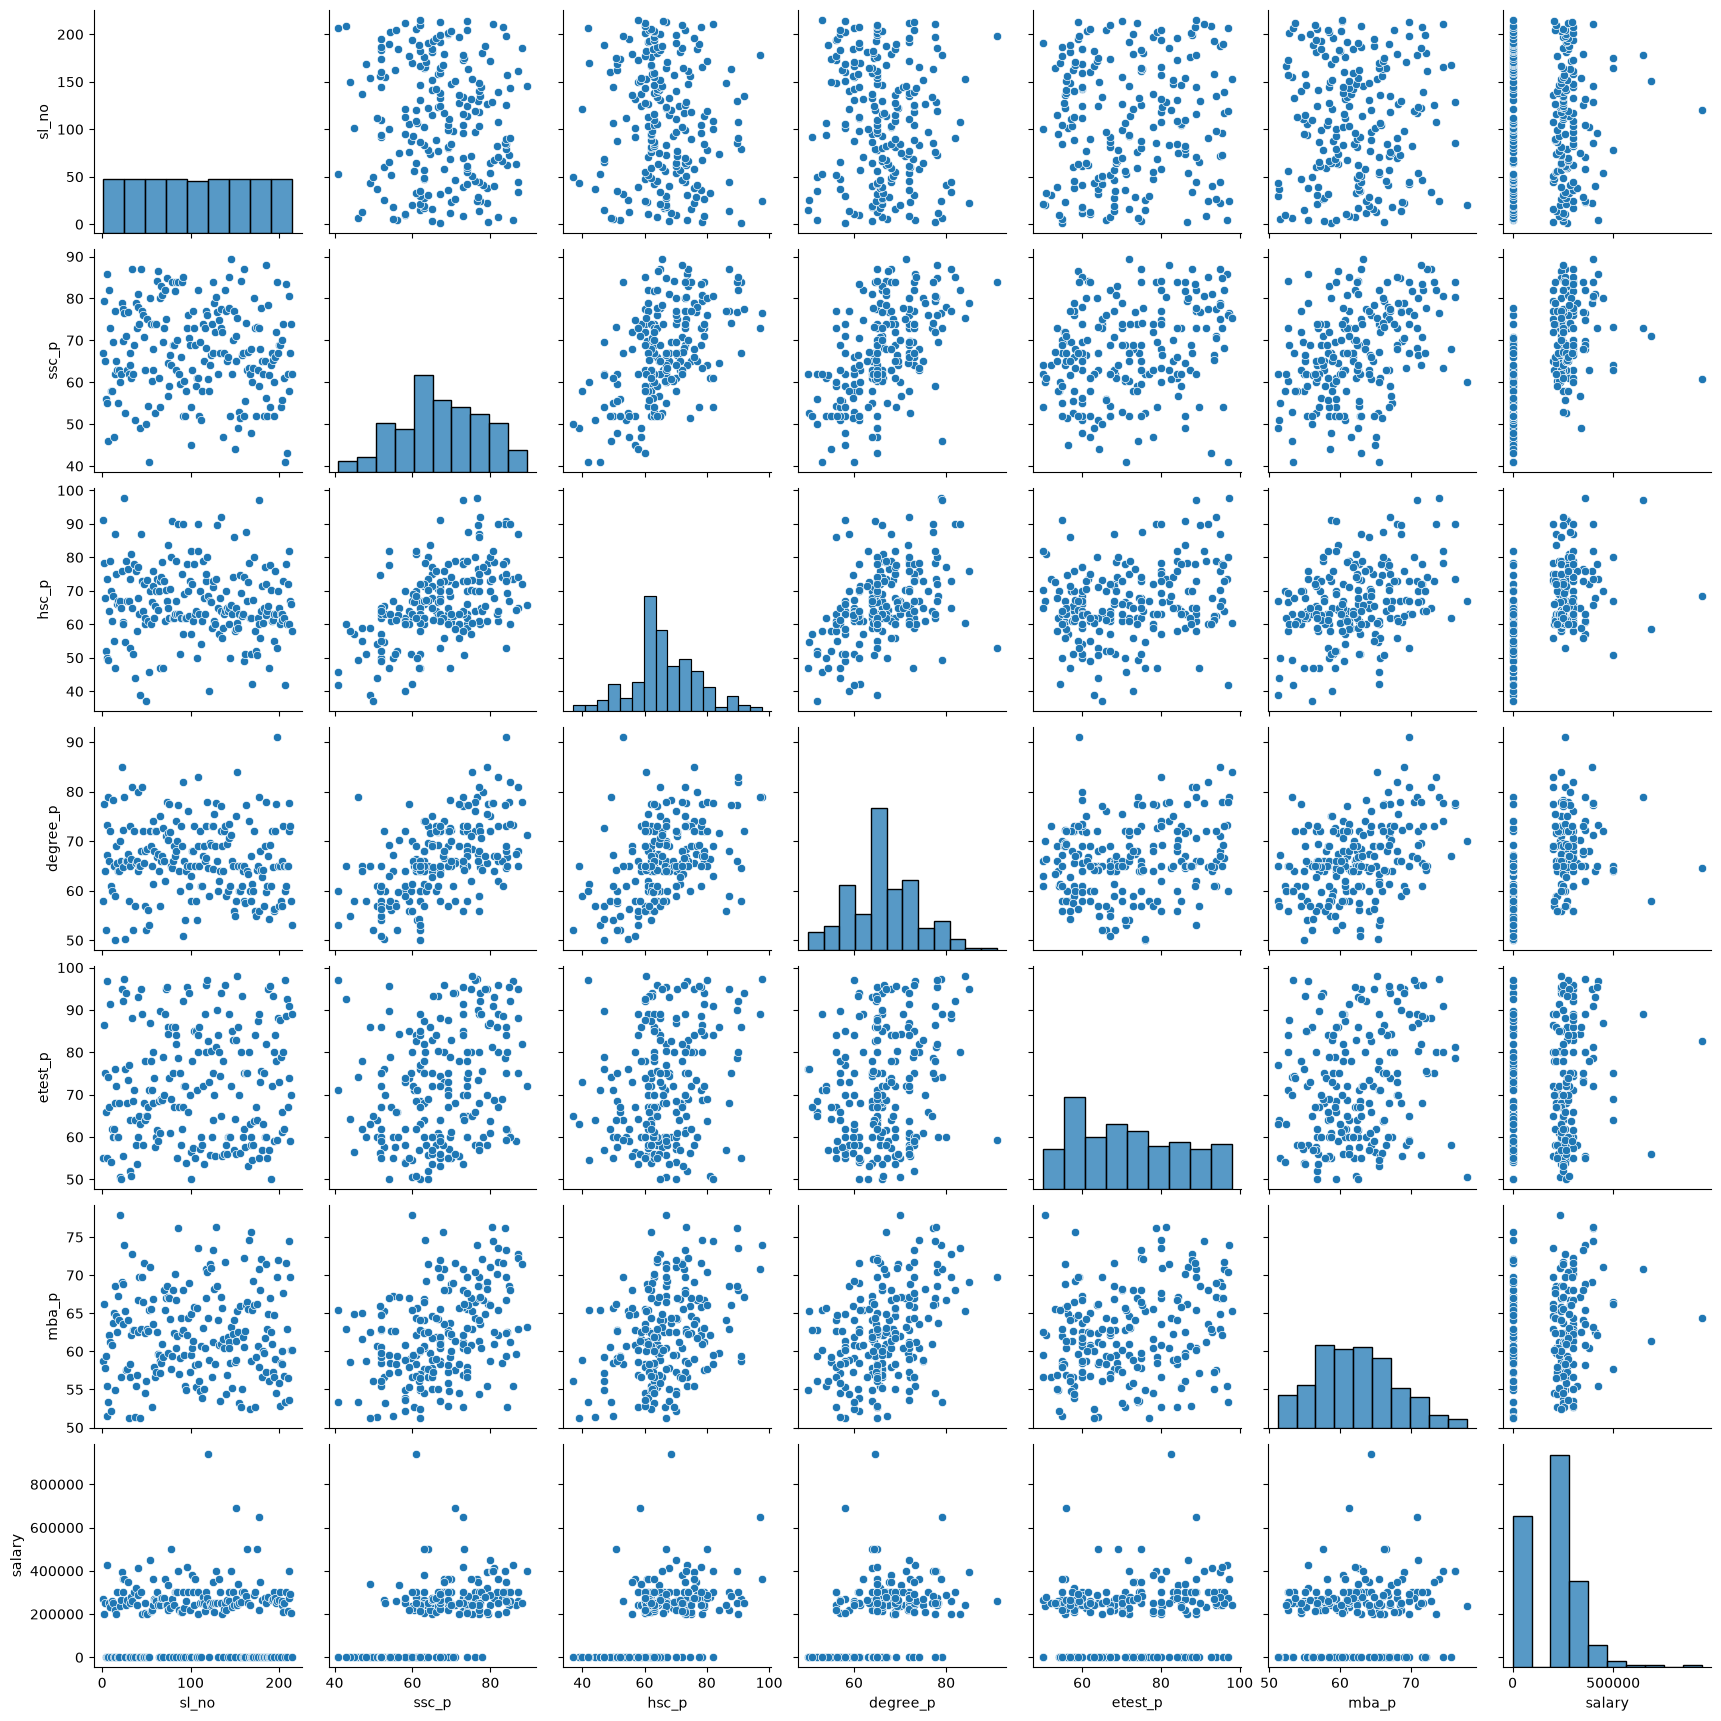

In [ ]:
#13 chart to explain
sns.pairplot(dataset)